<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from textblob import TextBlob

In [56]:
df = pd.read_csv ("/content/blogs.csv")

In [57]:
df

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism
...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc


#Removing StopWords


In [58]:
import nltk
from nltk.corpus import stopwords

# Download stopwords (only once)
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Applying Data Pre Processing Techniques

In [59]:
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\S+@\S+', '', text)  # Remove emails
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation
    tokens = text.split( )  # Tokenization (split into words)
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return ' '.join(tokens)




In [60]:
df['Cleaned_Data'] = df['Data'].apply(clean_text)

In [61]:
df['Cleaned_Data']

,Cleaned_Data
0,path cantaloupesrvcscmuedumagnesiumclubcccmued...
1,newsgroups altatheism path cantaloupesrvcscmue...
2,path cantaloupesrvcscmuedudasnewsharvardedunoc...
3,path cantaloupesrvcscmuedumagnesiumclubcccmued...
4,xref cantaloupesrvcscmuedu altatheism talkreli...
...,...
1995,xref cantaloupesrvcscmuedu talkabortion altath...
1996,xref cantaloupesrvcscmuedu talkreligionmisc ta...
1997,xref cantaloupesrvcscmuedu talkorigins talkrel...
1998,xref cantaloupesrvcscmuedu talkreligionmisc al...


# TF-IDF Feature Extraction

In [62]:

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['Cleaned_Data'])
y = df['Labels']


In [63]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180865 stored elements and shape (2000, 5000)>

In [64]:
y

,Labels
0,alt.atheism
1,alt.atheism
2,alt.atheism
3,alt.atheism
4,alt.atheism
...,...
1995,talk.religion.misc
1996,talk.religion.misc
1997,talk.religion.misc
1998,talk.religion.misc


# Split Data (80% train, 20% test)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#Training with Naive Bayes

In [80]:
# Train Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)
y_pred = nb_classifier.predict(X_test)


#Evaluation by using F1,Accuracy,Classification

In [81]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:\n', report)


Accuracy: 0.8375
Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.47      0.83      0.60        18
           comp.graphics       0.71      0.83      0.77        18
 comp.os.ms-windows.misc       0.91      0.95      0.93        22
comp.sys.ibm.pc.hardware       0.83      0.80      0.82        25
   comp.sys.mac.hardware       0.83      0.90      0.86        21
          comp.windows.x       1.00      0.84      0.91        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.94      0.94      0.94        18
         rec.motorcycles       0.88      0.94      0.91        16
      rec.sport.baseball       0.76      0.89      0.82        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.8

#TextBlob library for Sentiment Analysis

In [82]:
from textblob import TextBlob

In [83]:
# Sentiment Analysis
def get_sentiment(text):
    sentiment = TextBlob(text).sentiment.polarity
    if sentiment > 0:
        return "Positive"
    elif sentiment < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Data'].apply(get_sentiment)

#Sentimental Analysis Visualization



<ipython-input-84-f2ac86f2b31e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm')


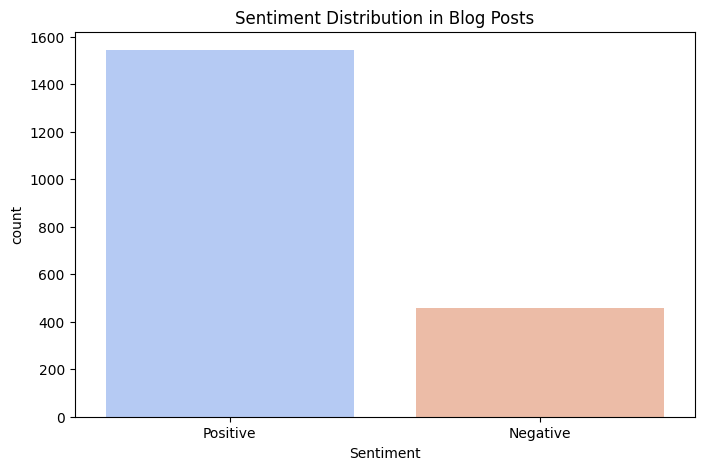

In [84]:
# Visualizing Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Sentiment'], palette='coolwarm')
plt.title('Sentiment Distribution in Blog Posts')
plt.show()

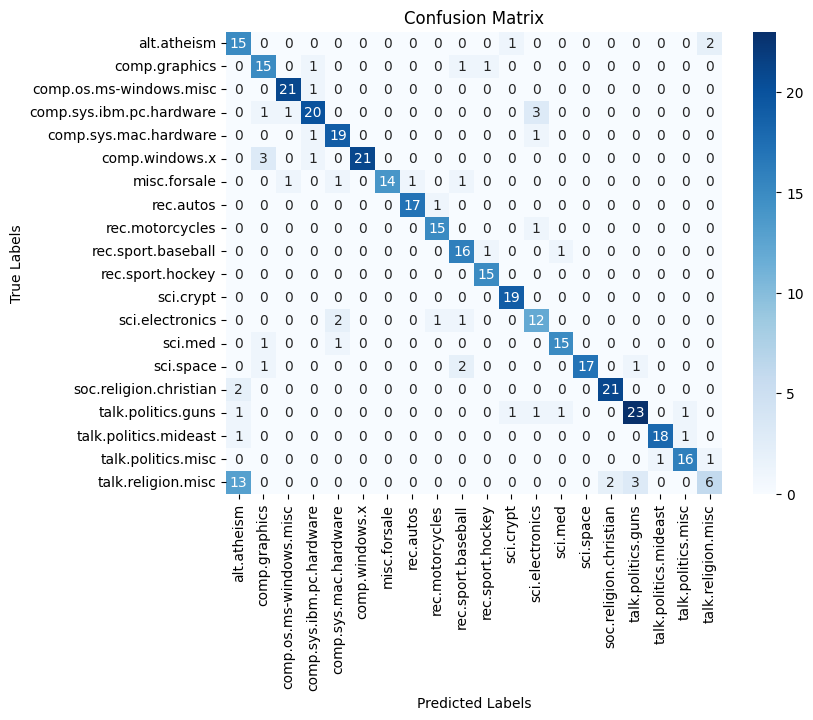

In [85]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=nb_classifier.classes_, yticklabels=nb_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Discussion

In [86]:

print("\nDiscussion:")
print("1. The Naive Bayes classifier is effective for text classification, achieving an accuracy of {:.2f}%".format(accuracy * 100))
print("2. Precision, Recall, and F1-score provide further insights into classification performance across different categories.")
print("3. The sentiment analysis reveals how different blog categories express positive, negative, or neutral sentiments.")



Discussion:
1. The Naive Bayes classifier is effective for text classification, achieving an accuracy of 83.75%
2. Precision, Recall, and F1-score provide further insights into classification performance across different categories.
3. The sentiment analysis reveals how different blog categories express positive, negative, or neutral sentiments.
